# Composition-Based Prediction of Ferroelectric Materials

## Objective

This notebook evaluates whether composition-based descriptors can separate materials labelled as potentially ferroelectric from the remaining entries in the Matminer dielectric dataset.

The input features are generated in `01_data_selection_and_preprocessing.ipynb`. The analysis compares several classification models under the same stratified cross-validation protocol and reports performance using metrics that are appropriate for a moderately imbalanced binary target.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from scipy.stats import loguniform, randint

RANDOM_STATE = 42
N_SPLITS = 5

DATA_PATH = Path("../data/dielectric_composition_features.csv")

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.10.21
pandas: 2.3.3
scikit-learn: 1.7.2


## 2. Load the processed dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1056, 122)


,material_id,formula,H,He,Li,Be,B,C,N,O,...,Rg,Cn,Nh,Fl,Mc,Lv,Ts,Og,target_ferroelectric,band_gap
0,mp-441,Rb2Te,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.88
1,mp-22881,CdCl2,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,3.52
2,mp-28013,MnI2,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.17
3,mp-567290,LaN,0.0,0,0.0,0.0,0.0,0.0,0.5,0.0,...,0,0,0,0,0,0,0,0,0,1.12
4,mp-560902,MnF2,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,2.87


In [3]:
target_col = "target_ferroelectric"
metadata_cols = [col for col in ["material_id", "formula", "band_gap", target_col] if col in df.columns]

feature_cols = [col for col in df.columns if col not in metadata_cols]

X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

print(f"Number of materials: {len(df)}")
print(f"Number of composition descriptors: {X.shape[1]}")
print(f"Positive class fraction: {y.mean():.3f}")

Number of materials: 1056
Number of composition descriptors: 118
Positive class fraction: 0.671


The target distribution is not balanced, so model comparison is based on more than accuracy alone. ROC-AUC and F1 score are used alongside precision, recall, and accuracy.

## 3. Cross-validation and scoring

In [4]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

Constant descriptors are removed inside each training fold using `VarianceThreshold`. Standardization is applied only to models that depend on feature scale.

## 4. Model definitions

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("variance", VarianceThreshold()),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "SVM": Pipeline([
        ("variance", VarianceThreshold()),
        ("scale", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("variance", VarianceThreshold()),
        ("model", RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("variance", VarianceThreshold()),
        ("model", GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        )),
    ]),
    "Neural Network": Pipeline([
        ("variance", VarianceThreshold()),
        ("scale", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=2000,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

## 5. Cross-validated model comparison

In [6]:
rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    row = {"model": name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std(ddof=1)

    rows.append(row)

results = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)
display(results.round(3))

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
2,Random Forest,0.934,0.016,0.868,0.020,0.888,0.021,0.921,0.023,0.904,0.014
3,Gradient Boosting,0.908,0.021,0.811,0.013,0.804,0.014,0.949,0.013,0.871,0.009
1,SVM,0.852,0.026,0.778,0.040,0.834,0.031,0.838,0.057,0.835,0.034
0,Logistic Regression,0.636,0.041,0.632,0.044,0.755,0.041,0.671,0.061,0.709,0.040
4,Neural Network,0.621,0.039,0.702,0.016,0.733,0.027,0.879,0.065,0.798,0.017


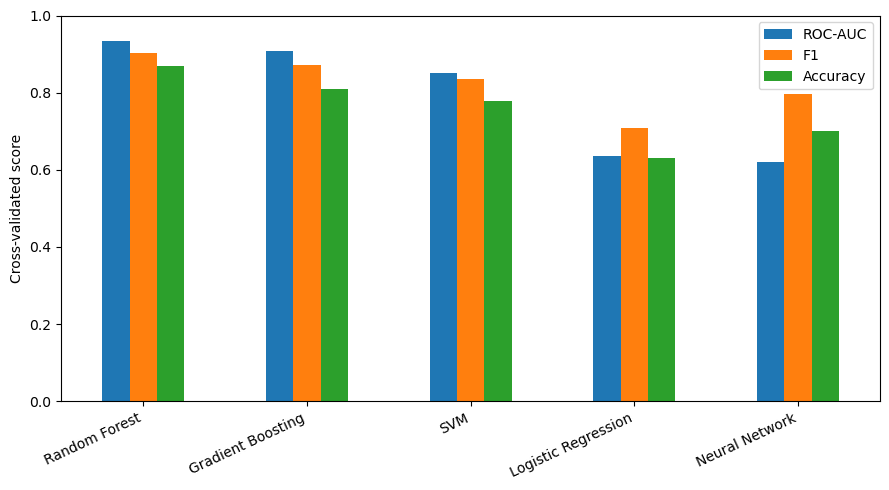

In [7]:
plot_df = results.set_index("model")[
    ["roc_auc_mean", "f1_mean", "accuracy_mean"]
]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Cross-validated score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(["ROC-AUC", "F1", "Accuracy"])
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The ranking is based primarily on cross-validated ROC-AUC. Differences should be interpreted together with their fold-to-fold variation rather than from the mean score alone.

## 6. Detailed evaluation of the strongest baseline

In [8]:
best_name = results.iloc[0]["model"]
best_model = models[best_name]

print(f"Selected baseline: {best_name}")

Selected baseline: Random Forest


In [9]:
y_pred = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    method="predict",
    n_jobs=-1,
)

y_prob = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

print(classification_report(y, y_pred, digits=3))
print(f"Out-of-fold ROC-AUC: {roc_auc_score(y, y_prob):.3f}")

              precision    recall  f1-score   support

           0      0.825     0.761     0.792       347
           1      0.887     0.921     0.904       709

    accuracy                          0.868      1056
   macro avg      0.856     0.841     0.848      1056
weighted avg      0.867     0.868     0.867      1056

Out-of-fold ROC-AUC: 0.934


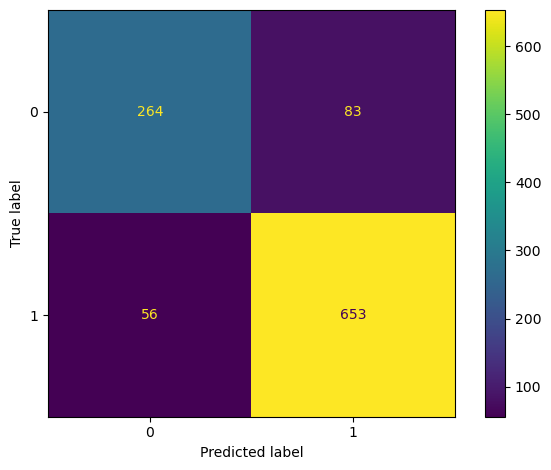

In [10]:
ConfusionMatrixDisplay.from_predictions(y, y_pred)
plt.tight_layout()
plt.show()

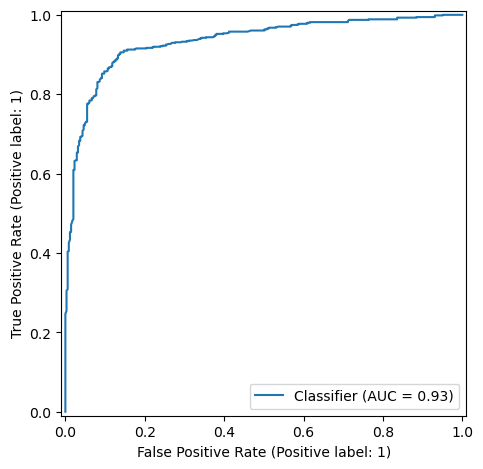

In [11]:
RocCurveDisplay.from_predictions(y, y_prob)
plt.tight_layout()
plt.show()

## 7. Random-forest tuning

The earlier analysis identified random forests as a strong baseline. Here, hyperparameter tuning is repeated using stratified cross-validation. The tuned model is compared with the untuned baseline rather than assumed to be better.

In [12]:
rf_pipeline = Pipeline([
    ("variance", VarianceThreshold()),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

param_distributions = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": [None, 6, 10, 14, 18, 24],
    "model__min_samples_split": randint(2, 12),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": ["sqrt", "log2", None],
    "model__max_samples": [None, 0.5, 0.7, 0.9],
}

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

search.fit(X, y)

print(f"Best cross-validated ROC-AUC: {search.best_score_:.3f}")
print("Best parameters:")
for key, value in search.best_params_.items():
    print(f"  {key}: {value}")

Best cross-validated ROC-AUC: 0.924
Best parameters:
  model__max_depth: None
  model__max_features: None
  model__max_samples: 0.5
  model__min_samples_leaf: 1
  model__min_samples_split: 2
  model__n_estimators: 576


The parameter search did not identify a configuration with a higher cross-validated ROC-AUC than the baseline random forest. The best configuration found during the search reached a mean ROC-AUC of 0.924, compared with 0.934 ± 0.016 for the baseline model. The tuning result is reported as a model-selection diagnostic rather than an independent estimate of generalization performance.

## 8. Feature interpretation

In [13]:
tuned_rf = search.best_estimator_
tuned_rf.fit(X, y)

variance_step = tuned_rf.named_steps["variance"]
rf_model = tuned_rf.named_steps["model"]

selected_mask = variance_step.get_support()
selected_features = X.columns[selected_mask]

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=selected_features,
).sort_values(ascending=False)

display(feature_importance.head(15).to_frame("importance"))

,importance
K,0.076149
Rb,0.067023
Li,0.047729
N,0.043316
O,0.042679
P,0.039582
Cs,0.037185
Na,0.036949
As,0.031436
Cl,0.031071


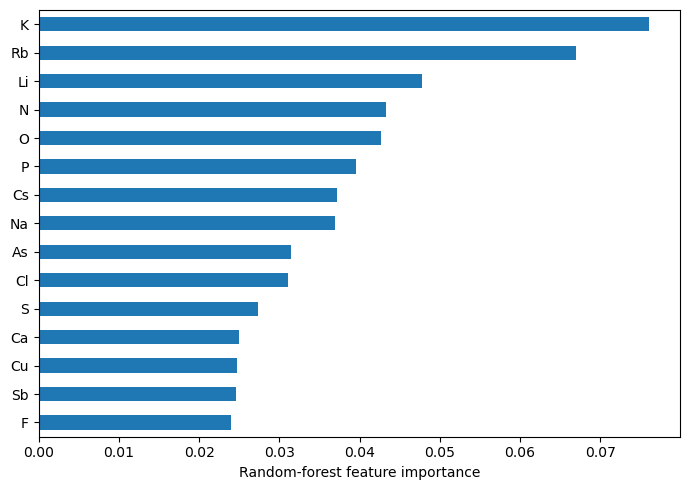

In [14]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(7, 5),
)
plt.xlabel("Random-forest feature importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

Tree-based feature importance is useful for ranking descriptors, but it does not establish a causal relationship between an element and ferroelectric behaviour. Correlated composition variables can also share or redistribute importance.

## 9. Permutation importance

In [15]:
permutation = permutation_importance(
    tuned_rf,
    X,
    y,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_scores = pd.Series(
    permutation.importances_mean,
    index=X.columns,
).sort_values(ascending=False)

display(permutation_scores.head(15).to_frame("mean_permutation_importance"))

,mean_permutation_importance
K,0.065709
Rb,0.045436
Cs,0.024145
Li,0.017471
N,0.014149
Cu,0.011452
O,0.010986
P,0.009395
Tl,0.008877
As,0.007561


Permutation importance measures the change in predictive performance when a feature is disrupted. It is included as a second view of feature relevance, although interpretation remains subject to feature correlation and dataset bias.

## 10. Summary

This analysis compares five classification approaches using the same composition-based feature set and stratified cross-validation.

The main conclusions should be taken from the executed results rather than fixed expectations:

- composition alone contains measurable predictive information for the target used here;
- model ranking depends on both mean performance and fold-to-fold variability;
- random-forest tuning is evaluated against its baseline rather than assumed to improve it;
- feature rankings indicate statistical associations in this dataset, not direct physical mechanisms.

The present feature representation does not include crystal structure, symmetry, processing history, defects, temperature, or other variables that can affect ferroelectric behaviour. The models should therefore be interpreted as composition-based classifiers rather than complete physical descriptions.